In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from cns.process.aggregation import group_samples, add_total_cn
from cns.utils.selection import get_cns_for_type, only_aut
from cns.display.plot import fig_lines
from cns.data_utils import main_load_data, select_CNS_samples, load_merged_samples, save_cns_fig

In [3]:
# set font size to 12
plt.rcParams.update({'font.size': 12})

In [4]:
load_merged_samples(print_info=True);

Total samples: 14174
PCAWG
Total samples: 2583
190 samples are CN neutral (below 0.00140)
3 samples have low coverage (below 0.97816)
Filtered samples: 2390
TRACERx
Total samples: 1620
0 samples are CN neutral (below 0.00010)
19 samples have low coverage (below 0.93514)
286 samples do not have exact type
Filtered samples: 1322
TCGA_hg19
Total samples: 9971
658 samples are CN neutral (below 0.00030)
16 samples have low coverage (below 0.99826)
Filtered samples: 9297
Total samples: 13009


In [5]:
bin_size = "5MB"
samples_df, cns_df = main_load_data(bin_size)
samples_df["type"].value_counts().head(6).sum()

5172

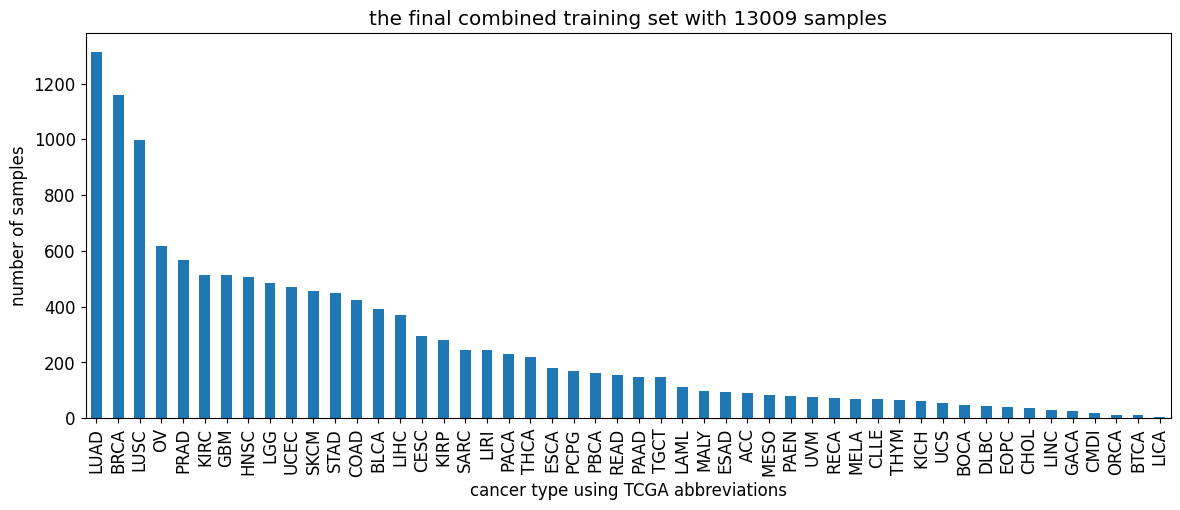

In [10]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
plt.title("the final combined training set with {} samples".format(len(samples_df)))
plt.ylabel("number of samples")
plt.xlabel("cancer type using TCGA abbreviations")
save_cns_fig("cancer_types")

In [7]:
top_6 = samples_df["type"].value_counts().head(6).index
top_6_cns_df = ([add_total_cn(group_samples(get_cns_for_type(cns_df, samples_df, cancer_type))) for cancer_type in top_6])

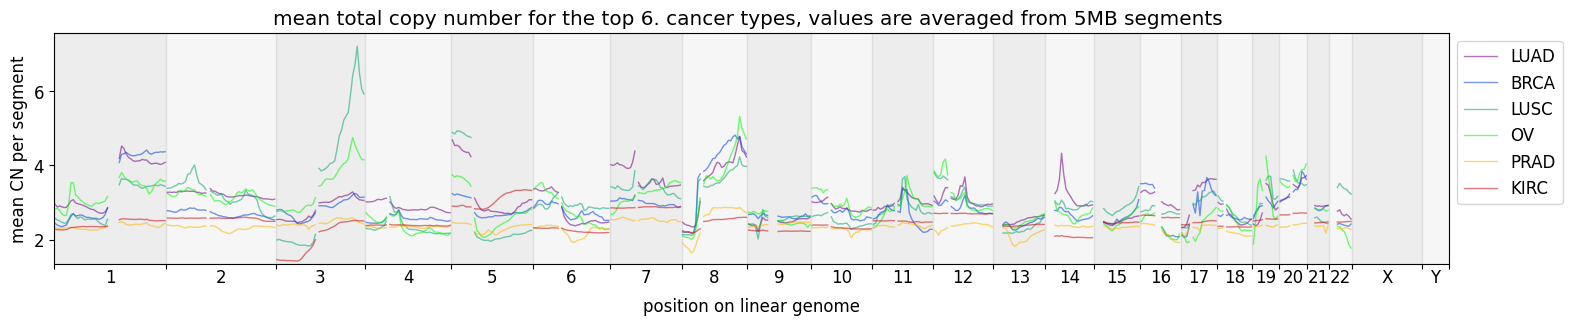

In [12]:
fig_lines([only_aut(x) for x in top_6_cns_df], top_6, column="total_cn")
plt.title(f"mean total copy number for the top 6. cancer types, values are averaged from {bin_size} segments ")
save_cns_fig("top_6_profiles")

Text(0.5, 1.0, 'mean total copy number for 40 types with at least 50 samples')

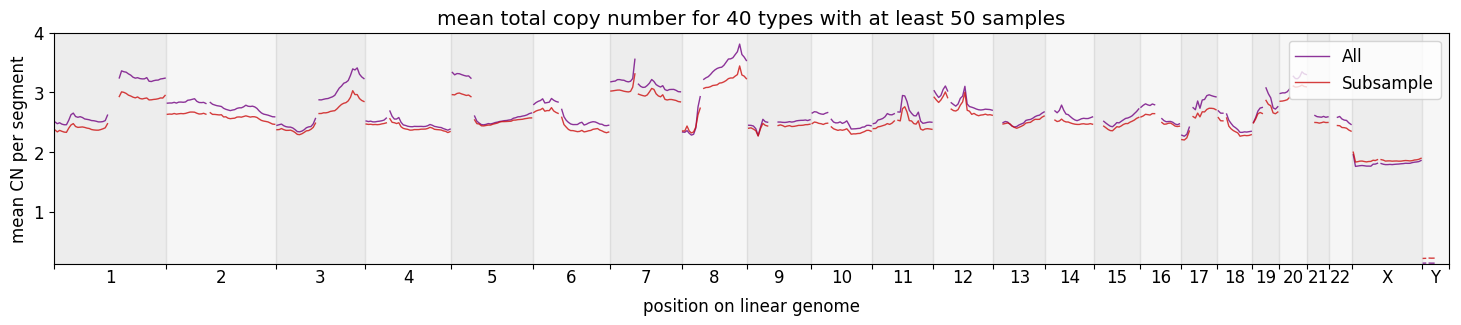

In [11]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.reset_index().groupby('type').apply(lambda x: x.sample(n=50, random_state=0), include_groups=False).set_index("sample_id")
# select only 50 samples for each type to obtain balanced mean
selection = [add_total_cn(group_samples(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn")
plt.title(f"mean total copy number for {len(above_50)} types with at least 50 samples")